# Sentiment, VADER vs transformer

Group 52, XB_0085 Text Mining

Test set: Sentiment-topic-test.tsv, columns: sentence id, text, sentiment, topic.
Labels: positive, neutral, negative.

In [53]:
import pandas as pd

df = pd.read_csv('../data/Sentiment-topic-test.tsv', sep='\t')

test_df = pd.DataFrame({'text': df.text, 
                      'labels':  [2 if senti.strip() == "positive" else 0 if senti.strip() == "negative" else 1 for senti in df.sentiment]})


df.head()

,sentence id,text,sentiment,topic
0,0,It took eight years for Warner Brothers to rec...,negative,movie
1,1,All the New York University students love this...,positive,restaurant
2,2,This Italian place is really trendy but they h...,negative,restaurant
3,3,"In conclusion, my review of this book would be...",positive,book
4,4,The story of this movie is focused on Carl Bra...,neutral,movie


## VADER

See Lab 3.2.

In [80]:
import nltk
from nltk.sentiment import vader
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

sentences = ["The flight was very boring, and once arrived the view was not what i expected.",
             "It's a very rainy day, which is great for all the dried up plants, given the bad heatwave the last few weeks.",
             "I've never seen such a terribly good player before!"]

for sent in sentences:
    scores = sid.polarity_scores(sent)
    print()
    print('INPUT SENTENCE', sent)
    print('VADER OUTPUT', scores)


INPUT SENTENCE The flight was very boring, and once arrived the view was not what i expected.
VADER OUTPUT {'neg': 0.166, 'neu': 0.834, 'pos': 0.0, 'compound': -0.3804}

INPUT SENTENCE It's a very rainy day, which is great for all the dried up plants, given the bad heatwave the last few weeks.
VADER OUTPUT {'neg': 0.187, 'neu': 0.662, 'pos': 0.151, 'compound': 0.0018}

INPUT SENTENCE I've never seen such a terribly good player before!
VADER OUTPUT {'neg': 0.0, 'neu': 0.495, 'pos': 0.505, 'compound': 0.7283}


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\skick\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [85]:
vader_predictions = []

for text in test_df.text:
    scores = sid.polarity_scores(text)

    compound = scores["compound"]

    pred = (
    2 if scores["compound"] >= 0.05
    else 0 if scores["compound"] <= -0.05
    else 1
    )

    vader_predictions.append(pred)

## Transformer

See Lab 3.4.

In [ ]:
from transformers import pipeline

# using a pre fine tuned model.
sentimentclassifier = pipeline("sentiment-analysis",
                               model="distilbert-base-uncased-finetuned-sst-2-english",
                               tokenizer="distilbert-base-uncased-finetuned-sst-2-english")

sentence1 = "The flight was very boring, and once arrived the view was not what i expected."
sentimentclassifier(sentence1)

Device set to use cpu


[{'label': 'NEGATIVE', 'score': 0.9996562004089355}]

In [ ]:
# load training data
import pandas as pd
from sklearn.model_selection import train_test_split

raw_data = pd.read_csv('../data/sentiment_analysis.csv')

train = pd.DataFrame({'text': raw_data.text, 
                      'labels':  [2 if senti.strip() == "positive" else 0 if senti.strip() == "negative" else 1 for senti in raw_data.sentiment]})

# Split data for a dev set
train, dev = train_test_split(train, test_size=0.15, random_state=0,
                               stratify=train['labels'])

print(train)

                                                  text  labels
200                   Family is here,hanging with them       1
448  I don`t want to sit at home on prom night. Som...       0
116   Haha I know, I cant handle the fame!  and tha...       2
59       im thinking that im going to have fun tonight       2
90                    Follow me, I will follow you too       1
..                                                 ...     ...
73                                          Soooo high       1
460   'there are people and then there are pencils'...       1
307  Live That`s what I want. More the better. Boun...       1
335  My dog is officially depressed that my brother...       0
413  I sure do hope it becomes 4:20 this afternoon ...       2

[424 rows x 2 columns]


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\simpletransformers\classification\classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(
1it [00:12, 12.09s/it]
Epochs 1/2. Running Loss:    0.9784: 100%|██████████| 14/14 [06:53<00:00, 29.54s/it]
1it [00:18, 18.06s/it]
Epochs 2/2. Running Loss:    1.0405: 100%|██████████| 14/14 [05:40<00:00, 24.35s/it]
1it [00:17, 17.88s/it]
Epoch 2 of 2: 100%|██████████| 2/2 [13:41<00:00, 410.84s/it]
1it [00:13, 13.96s/it]
Running Evaluation: 100%|██████████| 1/1 [00:11<00:00, 11.30s/it]


              precision    recall  f1-score   support

    negative       1.00      0.05      0.10        20
     neutral       0.56      0.67      0.61        30
    positive       0.50      0.76      0.60        25

    accuracy                           0.53        75
   macro avg       0.69      0.49      0.43        75
weighted avg       0.66      0.53      0.47        75

Confusion Matrix:
[[ 1 10  9]
 [ 0 20 10]
 [ 0  6 19]]


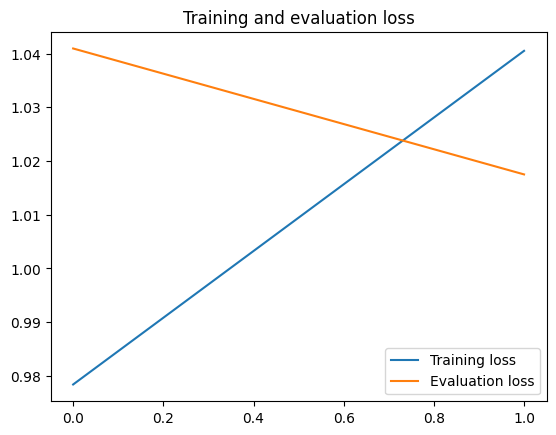

In [ ]:
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

# Define model arguments
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True 
model_args.evaluate_during_training=True 

model_args.num_train_epochs=2
model_args.train_batch_size=32
model_args.learning_rate=12e-6 
model_args.max_seq_length=256 

model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32


model = ClassificationModel('bert', 'bert-base-uncased', num_labels=3, args=model_args, use_cuda=False) 
_, history = model.train_model(train, eval_df=dev)
# torch.save(model, 'model_checkpoint.pth')
model.save_model("saved_model")

# Show the losses of the model
train_loss = history['train_loss']
eval_loss = history['eval_loss']

plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

# Evaluating on the dev set
result, model_outputs, wrong_predictions = model.eval_model(dev)

predictions = np.argmax(model_outputs, axis=1)
true_labels = dev["labels"].values

report = classification_report(
    true_labels,
    predictions,
    target_names=["negative", "neutral", "positive"]
)

print(report)

cm = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:")
print(cm)

## Evaluation and error analysis

In [86]:
#CODE FOR VADER MODEL
print("VADER")

true_labels = test_df.labels

report_vader = classification_report(
    true_labels,
    vader_predictions,
    target_names=["negative", "neutral", "positive"]
)

print(report_vader)

cm_vader = confusion_matrix(true_labels, vader_predictions)

print("Confusion Matrix:")
print(cm_vader)

VADER
              precision    recall  f1-score   support

    negative       1.00      0.33      0.50         3
     neutral       1.00      0.33      0.50         3
    positive       0.50      1.00      0.67         4

    accuracy                           0.60        10
   macro avg       0.83      0.56      0.56        10
weighted avg       0.80      0.60      0.57        10

Confusion Matrix:
[[1 0 2]
 [0 1 2]
 [0 0 4]]


In [78]:
print("Pre Fine-Tuned model")
true_labels = test_df.labels
pred_labels = []
for text_sentence in test_df.text:
    score = sentimentclassifier(text_sentence)
    score = score[0]

    text_prediction = 1
    if score["label"] == "NEGATIVE" and score["score"] > 0.5:
        text_prediction = 0
    elif score["label"] == "POSITIVE" and score["score"] > 0.5:
        text_prediction = 2
    
    pred_labels.append(text_prediction)


report_pre_fine_tuned = classification_report(
    true_labels,
    pred_labels,
    target_names=["negative", "neutral", "positive"]
)

print(report_pre_fine_tuned)

cm_pre_fine_tuned = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm_pre_fine_tuned)

Pre Fine-Tuned model
              precision    recall  f1-score   support

    negative       0.60      1.00      0.75         3
     neutral       0.00      0.00      0.00         3
    positive       0.80      1.00      0.89         4

    accuracy                           0.70        10
   macro avg       0.47      0.67      0.55        10
weighted avg       0.50      0.70      0.58        10

Confusion Matrix:
[[3 0 0]
 [2 0 1]
 [0 0 4]]


c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


The pre fine tuned model does not have a neutral class.
It predicts with high scores that sentences are either positive or negative

In [79]:

print("Self Fine-Tuned model")

result, model_outputs, wrong_predictions = model.eval_model(test_df)

predictions = np.argmax(model_outputs, axis=1)
true_labels = test_df["labels"].values

report = classification_report(
    true_labels,
    predictions,
    target_names=["negative", "neutral", "positive"]
)

print(report)

cm = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:")
print(cm)

Self Fine-Tuned model


1it [00:18, 18.82s/it]
Running Evaluation: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.25      0.33      0.29         3
    positive       0.50      0.75      0.60         4

    accuracy                           0.40        10
   macro avg       0.25      0.36      0.30        10
weighted avg       0.28      0.40      0.33        10

Confusion Matrix:
[[0 2 1]
 [0 1 2]
 [0 1 3]]



c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


The self fine tuned model never predicts negative and leans positive. The training loss stayed around chance and even went up between the two epochs (0.978 to 1.040), so it underfit, two epochs at a learning rate of 12e-6 was not enough to train it. With more epochs and a higher learning rate this is the one we would expect to improve most.

In [87]:
#ERROR ANALYSIS TABLE COMPARISON BETWEEN TRANSFORMER AND VADER

comparison_df = pd.DataFrame({
    "text": test_df.text,
    "true": true_labels,
    "vader": vader_predictions,
    "transformer": pred_labels,
    "fine_tuned": predictions
})

comparison_df.head()

,text,true,vader,transformer,fine_tuned
0,It took eight years for Warner Brothers to rec...,0,0,0,1
1,All the New York University students love this...,2,2,2,2
2,This Italian place is really trendy but they h...,0,2,0,2
3,"In conclusion, my review of this book would be...",2,2,2,2
4,The story of this movie is focused on Carl Bra...,1,2,2,2


In [93]:
#FAIL/SUCCES COMPARISON BETWEEN OTHER MODELS
# print(comparison_df)

transformer_over_VADER = comparison_df[
    (comparison_df["true"] == comparison_df["transformer"]) &
    (comparison_df["true"] != comparison_df["vader"])
]

print("Transformer over VADER")
print(transformer_over_VADER[["text", "true", "vader", "transformer"]].head(20))
print("")

VADER_over_transformer = comparison_df[
    (comparison_df["true"] == comparison_df["vader"]) &
    (comparison_df["true"] != comparison_df["transformer"])
]

print("VADER over transformer")
print(VADER_over_transformer[["text", "true", "vader", "transformer"]].head(20))
print("")

fine_tuned_over_VADER = comparison_df[
    (comparison_df["true"] == comparison_df["fine_tuned"]) &
    (comparison_df["true"] != comparison_df["vader"])
]

print("Fine tuned over VADER")
print(fine_tuned_over_VADER[
    ["text", "true", "vader", "fine_tuned"]
].head(20))

Transformer over VADER
                                                text  true  vader  transformer
2  This Italian place is really trendy but they h...     0      2            0
9  I always have loved English novels, but I just...     0      2            0

VADER over transformer
                                                text  true  vader  transformer
8  The new movie by Mr. Kruno was shot in New Yor...     1      1            0

Fine tuned over VADER
Empty DataFrame
Columns: [text, true, vader, fine_tuned]
Index: []


c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\skick\anaconda3\envs\TM\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\U

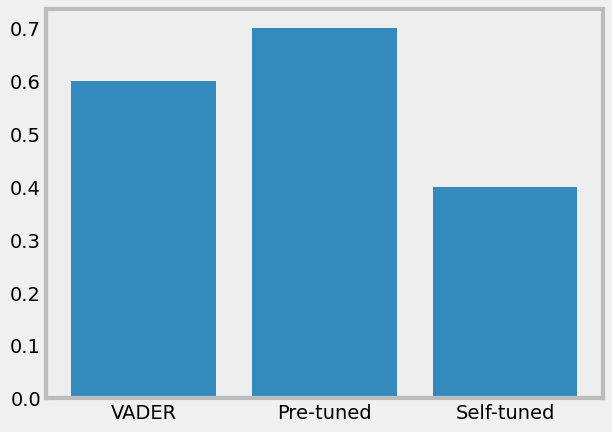

In [112]:
import matplotlib.pyplot as plt

report_vader_dict = classification_report(
    true_labels,
    vader_predictions,
    target_names=["negative", "neutral", "positive"],
    output_dict=True
)

report_pre_fine_tuned_dict = classification_report(
    true_labels,
    pred_labels,
    target_names=["negative", "neutral", "positive"],
    output_dict=True
)

report_self_dict = classification_report(
    true_labels,
    predictions,
    target_names=["negative", "neutral", "positive"],
    output_dict=True
)

accuracys = []

accuracys.append(report_vader_dict["accuracy"])
accuracys.append(report_pre_fine_tuned_dict["accuracy"])
accuracys.append(report_self_dict["accuracy"])

plt.style.use("bmh")
plt.grid(None)
plt.bar(["VADER", "Pre-tuned", "Self-tuned"], accuracys, )
plt.show()

## Follow-up: corrected learning rate

The self fine-tuned model above underfit: at a learning rate of 12e-6 for 2 epochs the loss barely moved. Here we test that diagnosis by retraining at 2e-5 (the value Sun et al. 2019 recommend) for more epochs and watching the evaluation loss.

In [ ]:
# Retrain at the learning rate Sun et al. (2019) recommend (2e-5), for more epochs,
# to test the underfitting diagnosis. Reuses train / dev / test_df from above.
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

args = ClassificationArgs()
args.overwrite_output_dir = True
args.evaluate_during_training = True
args.evaluate_during_training_steps = 10000 # only at epoch ends -> clean curve
args.num_train_epochs = 8
args.train_batch_size = 32
args.learning_rate = 2e-5 # the fix (was 12e-6)
args.max_seq_length = 128
args.manual_seed = 0
args.use_early_stopping = False

fixed = ClassificationModel('bert', 'bert-base-uncased', num_labels=3, args=args, use_cuda=False)
_, history = fixed.train_model(train, eval_df=dev)

plt.style.use('bmh')
plt.plot(range(1, len(history['eval_loss']) + 1), history['eval_loss'], marker='o')
plt.title('Sentiment fine-tune eval loss (LR 2e-5)')
plt.xlabel('epoch'); plt.ylabel('eval loss'); plt.grid(None)
plt.show()

for name, d in [('DEV', dev), ('TEST', test_df)]:
    _, outs, _ = fixed.eval_model(d)
    preds = np.argmax(outs, axis=1)
    print(name)
    print(classification_report(d['labels'].values, preds,
          target_names=['negative', 'neutral', 'positive'], zero_division=0))

On our run the evaluation loss falls every epoch (about 0.99 to 0.65 over the 8 epochs), where the original 12e-6 / 2 epoch run rose (0.978 to 1.040). Dev accuracy rises to around 0.76, so the model is now actually learning instead of underfitting. On the 10 sentence test the corrected model is unstable (around 0.50 to 0.60) and still does not beat the off the shelf DistilBERT. We put that down to the tiny test set and the domain gap, our training data is tweet style while the test sentences are reviews. The exact test numbers vary between runs, so we read the loss curve and the dev accuracy as the reliable evidence that the fix worked.